# Exploratory Data Analysis + Skill Analysis CareerPath AI

Notebook ini melakukan **Exploratory Data Analysis (EDA)** dan **Skill Analysis** untuk project **CareerPath AI**.

Dataset yang digunakan:
- `job_clean_final.csv`: dataset lowongan kerja hasil cleaning.
- `job_skills.csv`: relasi antara lowongan dan kode skill.
- `skills.csv`: master data kode skill dan nama skill.

Tujuan utama notebook ini adalah menghasilkan insight pasar kerja, skill yang paling banyak dicari, hubungan antara pekerjaan dan skill, serta dataset lanjutan untuk dashboard Streamlit dan pengembangan sistem rekomendasi AI.

## 1. Import Library

Library yang digunakan berfokus pada manipulasi data dan visualisasi profesional.

In [1]:
import pandas as pd
import numpy as np
import matplotlib

# Backend non-interaktif hanya dipakai jika notebook dieksekusi di luar Jupyter.
try:
    get_ipython
except NameError:
    matplotlib.use('Agg')

import matplotlib.pyplot as plt
import seaborn as sns

try:
    display
except NameError:
    def display(obj):
        print(obj)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

## 2. Load Dataset

Pada tahap ini seluruh dataset dimuat, lalu diperiksa ukuran, contoh data, dan nama kolomnya.

In [2]:
jobs = pd.read_csv('job_clean_final.csv')
job_skills = pd.read_csv('job_skills.csv')
skills = pd.read_csv('skills.csv')

datasets = {
    'job_clean_final': jobs,
    'job_skills': job_skills,
    'skills': skills
}

for name, data in datasets.items():
    print(f'{name}: {data.shape[0]:,} baris x {data.shape[1]:,} kolom')
    print(f'Kolom: {data.columns.tolist()}')
    display(data.head())
    print('-' * 80)

job_clean_final: 4,075 baris x 11 kolom
Kolom: ['job_id', 'title', 'description', 'job_posting_url', 'formatted_experience_level', 'formatted_work_type', 'location', 'remote_allowed', 'original_listed_time', 'listed_time', 'days_since_posted']


,job_id,title,description,job_posting_url,formatted_experience_level,formatted_work_type,location,remote_allowed,original_listed_time,listed_time,days_since_posted
0,2371637339,sales executive,are you a smart authentic pro active b2b sales professional are you a great listener and a problem solver who is com...,https://www.linkedin.com/jobs/view/2371637339/?trk=jobs_biz_prem_srch,not_specified,Full-time,Central Jakarta,0,2026-04-17 04:17:55,2026-04-17 04:21:06,10.0
1,3486411410,partnership associate,building strong strategic relationship with existing partnersget the insights synthesis and create impactful program...,https://www.linkedin.com/jobs/view/3486411410/?trk=jobs_biz_prem_srch,not_specified,Full-time,South Jakarta,0,2026-04-20 07:44:34,2026-04-20 07:44:34,7.0
2,3506214686,human resources coordinator,we re hiring fleet supervisor pt surya mitra tirta kencana membuka peluang bagi profesional berpengalaman di bidang ...,https://www.linkedin.com/jobs/view/3506214686/?trk=jobs_biz_prem_srch,not_specified,Full-time,Surabaya,0,2026-04-20 02:20:10,2026-04-20 02:20:10,7.0
3,3611210067,finance accounting specialist,engage in the monthly financial close process including ensuring all costs incurred are properly recorded reviewing ...,https://www.linkedin.com/jobs/view/3611210067/?trk=jobs_biz_prem_srch,Mid-Senior level,Full-time,Jakarta,0,2023-04-23 09:52:42,2026-04-20 13:13:27,7.0
4,3645884531,sales marketing for marine offshore,kualifikasi pendidikan minimal d3 s1 di bidang pemasaran teknik perkapalan atau manajemen.pengalaman minimal 2 tahun...,https://www.linkedin.com/jobs/view/3645884531/?trk=jobs_biz_prem_srch,not_specified,Full-time,Jakarta Metropolitan Area,0,2026-04-21 04:34:39,2026-04-21 04:34:39,6.0


--------------------------------------------------------------------------------
job_skills: 6,858 baris x 2 kolom
Kolom: ['job_id', 'skill_abr']


,job_id,skill_abr
0,4401464202,DSGN
1,4401464202,ART
2,4401464202,IT
3,4398796723,SALE
4,4398796723,BD


--------------------------------------------------------------------------------
skills: 35 baris x 2 kolom
Kolom: ['skill_abr', 'skill_name']


,skill_abr,skill_name
0,DIST,Distribution
1,HCPR,Health Care Provider
2,GENB,General Business
3,PRCH,Purchasing
4,LGL,Legal


--------------------------------------------------------------------------------


## 3. Validasi Data Awal

Validasi awal dilakukan untuk mengecek missing values, duplikasi, dan tipe data. Tujuannya adalah memastikan dataset cukup siap untuk analisis eksploratif dan merge antar tabel.

In [3]:
def audit_dataset(data, dataset_name):
    audit = pd.DataFrame({
        'dataset': dataset_name,
        'kolom': data.columns,
        'tipe_data': data.dtypes.astype(str).values,
        'missing_count': data.isna().sum().values,
        'missing_percent': (data.isna().mean() * 100).round(2).values,
        'unique_values': data.nunique(dropna=False).values
    })
    return audit

audit_all = pd.concat([
    audit_dataset(jobs, 'job_clean_final'),
    audit_dataset(job_skills, 'job_skills'),
    audit_dataset(skills, 'skills')
], ignore_index=True)

audit_all.sort_values(['dataset', 'missing_percent'], ascending=[True, False])

,dataset,kolom,tipe_data,missing_count,missing_percent,unique_values
1,job_clean_final,title,object,37,0.91,3166
2,job_clean_final,description,object,3,0.07,3672
0,job_clean_final,job_id,int64,0,0.00,4075
3,job_clean_final,job_posting_url,object,0,0.00,4075
4,job_clean_final,formatted_experience_level,object,0,0.00,7
5,job_clean_final,formatted_work_type,object,0,0.00,7
6,job_clean_final,location,object,0,0.00,298
7,job_clean_final,remote_allowed,int64,0,0.00,2
8,job_clean_final,original_listed_time,object,0,0.00,3907
9,job_clean_final,listed_time,object,0,0.00,3861


In [4]:
duplicate_summary = pd.DataFrame({
    'dataset': ['job_clean_final', 'job_skills', 'skills'],
    'duplicate_rows': [jobs.duplicated().sum(), job_skills.duplicated().sum(), skills.duplicated().sum()]
})

duplicate_summary

,dataset,duplicate_rows
0,job_clean_final,0
1,job_skills,0
2,skills,0


### Insight Validasi Data

Secara umum dataset sudah siap dianalisis karena kolom kunci `job_id` tersedia pada dataset lowongan dan relasi skill. Dataset `skills.csv` juga menyediakan master nama skill yang dapat digunakan untuk memperkaya analisis. Missing values yang tersisa masih dapat diterima untuk EDA selama tidak berada pada kolom kunci analisis utama seperti `job_id`, `title`, `location`, dan `skill_abr`.

## 4. EDA Dataset Lowongan

Bagian ini menganalisis pola umum pasar kerja berdasarkan title, lokasi, tipe kerja, level pengalaman, dan tren waktu posting.

### A. Top 10 Job Title

Analisis ini melihat pekerjaan yang paling sering muncul pada dataset. Frekuensi tinggi mengindikasikan kebutuhan pasar yang relatif besar terhadap role tersebut.

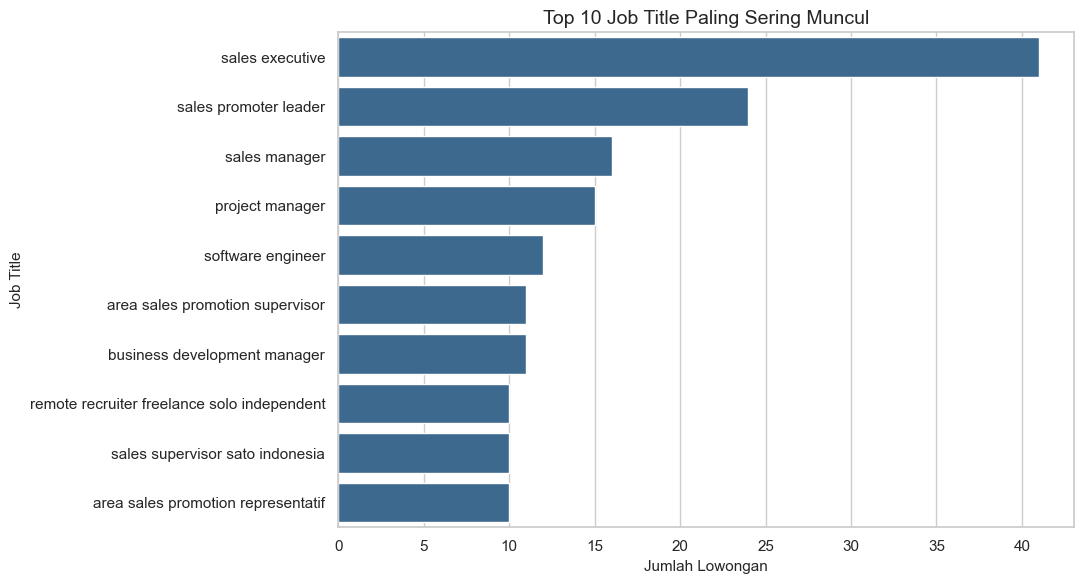

,title,jumlah_lowongan
0,sales executive,41
1,sales promoter leader,24
2,sales manager,16
3,project manager,15
4,software engineer,12
5,area sales promotion supervisor,11
6,business development manager,11
7,remote recruiter freelance solo independent,10
8,sales supervisor sato indonesia,10
9,area sales promotion representatif,10


In [5]:
top_titles = jobs['title'].value_counts().head(10).reset_index()
top_titles.columns = ['title', 'jumlah_lowongan']

plt.figure(figsize=(11, 6))
sns.barplot(data=top_titles, x='jumlah_lowongan', y='title', color='#2F6B9A')
plt.title('Top 10 Job Title Paling Sering Muncul')
plt.xlabel('Jumlah Lowongan')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()

top_titles

**Insight:** Pekerjaan yang paling sering muncul menunjukkan area dengan permintaan pasar tertinggi. Role pada daftar teratas dapat menjadi prioritas untuk dashboard CareerPath AI, terutama sebagai filter rekomendasi dan target benchmark skill pengguna.

### B. Top 10 Location

Analisis lokasi membantu mengidentifikasi kota atau wilayah dengan peluang kerja terbesar.

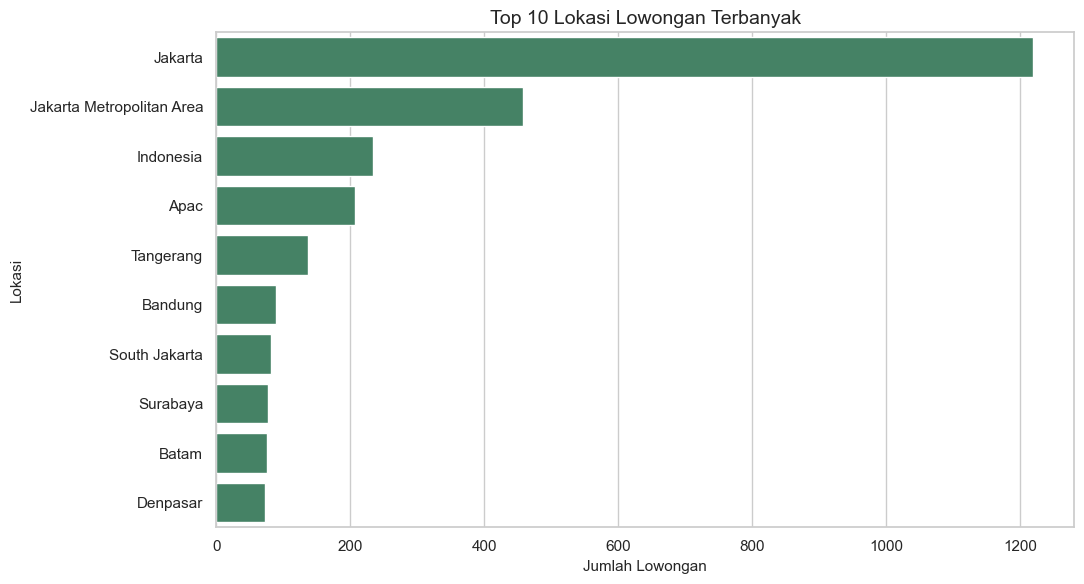

,location,jumlah_lowongan
0,Jakarta,1219
1,Jakarta Metropolitan Area,457
2,Indonesia,234
3,Apac,207
4,Tangerang,136
5,Bandung,89
6,South Jakarta,81
7,Surabaya,77
8,Batam,76
9,Denpasar,72


In [6]:
top_locations = jobs['location'].value_counts().head(10).reset_index()
top_locations.columns = ['location', 'jumlah_lowongan']

plt.figure(figsize=(11, 6))
sns.barplot(data=top_locations, x='jumlah_lowongan', y='location', color='#3B8C66')
plt.title('Top 10 Lokasi Lowongan Terbanyak')
plt.xlabel('Jumlah Lowongan')
plt.ylabel('Lokasi')
plt.tight_layout()
plt.show()

top_locations

**Insight:** Lokasi dengan jumlah lowongan terbanyak menunjukkan pusat aktivitas rekrutmen. Informasi ini penting untuk fitur dashboard seperti heatmap peluang kerja, filter lokasi, dan rekomendasi berbasis preferensi kota pengguna.

### C. Work Type

Distribusi `formatted_work_type` digunakan untuk melihat dominasi tipe pekerjaan seperti full-time, contract, part-time, internship, atau tipe lainnya.

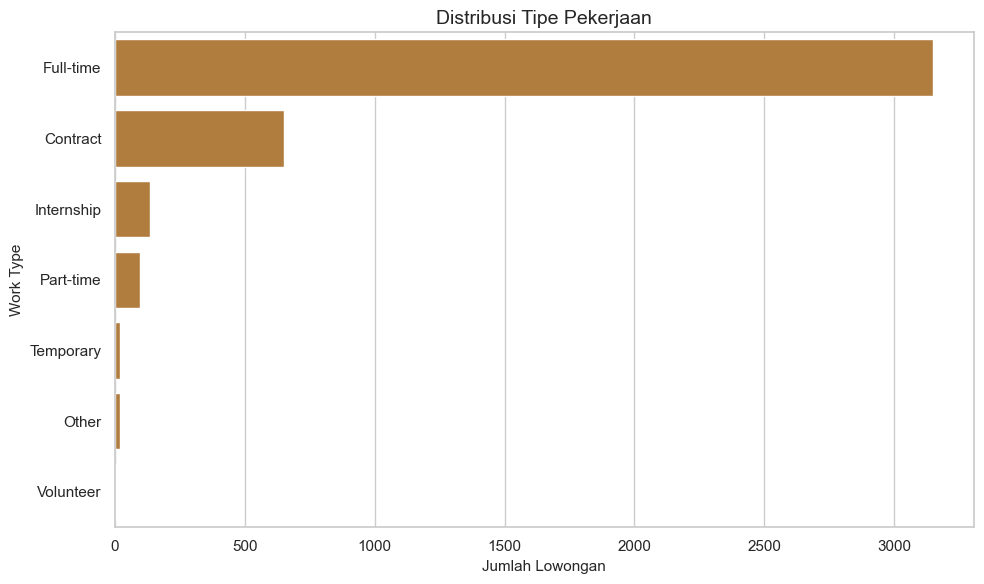

,formatted_work_type,jumlah_lowongan
0,Full-time,3149
1,Contract,650
2,Internship,134
3,Part-time,96
4,Temporary,20
5,Other,20
6,Volunteer,6


In [7]:
work_type_counts = jobs['formatted_work_type'].fillna('not_specified').value_counts().reset_index()
work_type_counts.columns = ['formatted_work_type', 'jumlah_lowongan']

plt.figure(figsize=(10, 6))
sns.barplot(data=work_type_counts, x='jumlah_lowongan', y='formatted_work_type', color='#C47F2C')
plt.title('Distribusi Tipe Pekerjaan')
plt.xlabel('Jumlah Lowongan')
plt.ylabel('Work Type')
plt.tight_layout()
plt.show()

work_type_counts

**Insight:** Dominasi tipe pekerjaan tertentu, terutama full-time jika menjadi kategori terbesar, menunjukkan pola kebutuhan tenaga kerja yang lebih stabil. Untuk CareerPath AI, informasi ini dapat digunakan sebagai filter preferensi kerja dan konteks rekomendasi karier.

### D. Experience Level

Analisis level pengalaman membantu memahami apakah pasar lebih banyak membutuhkan fresh graduate, junior, mid-level, senior, atau kandidat dengan pengalaman tidak dispesifikasikan.

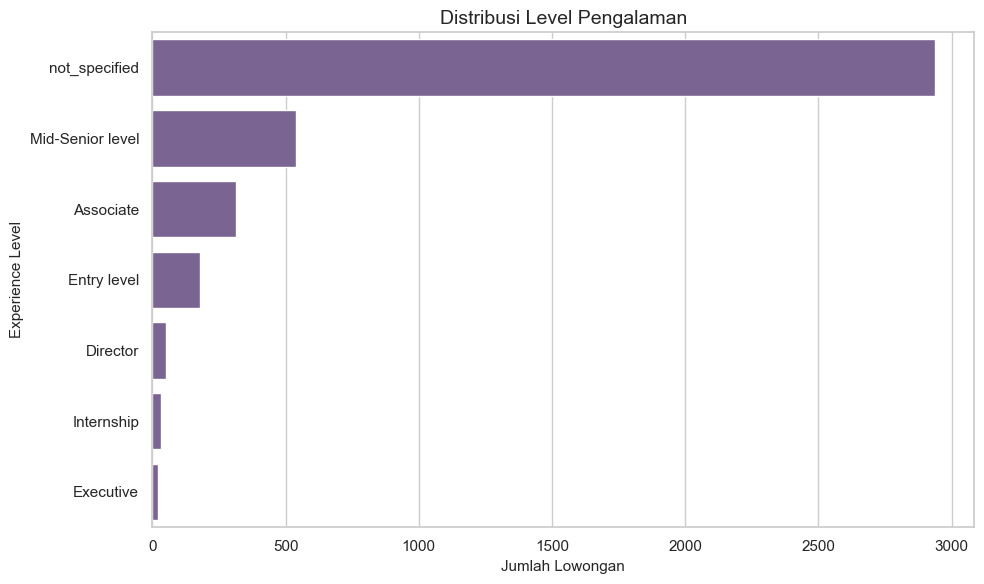

,formatted_experience_level,jumlah_lowongan
0,not_specified,2937
1,Mid-Senior level,539
2,Associate,315
3,Entry level,178
4,Director,51
5,Internship,33
6,Executive,22


In [8]:
experience_counts = jobs['formatted_experience_level'].fillna('not_specified').value_counts().reset_index()
experience_counts.columns = ['formatted_experience_level', 'jumlah_lowongan']

plt.figure(figsize=(10, 6))
sns.barplot(data=experience_counts, x='jumlah_lowongan', y='formatted_experience_level', color='#7A5C99')
plt.title('Distribusi Level Pengalaman')
plt.xlabel('Jumlah Lowongan')
plt.ylabel('Experience Level')
plt.tight_layout()
plt.show()

experience_counts

**Insight:** Jika kategori `not_specified` dominan, banyak perusahaan tidak secara eksplisit menulis level pengalaman. Hal ini penting bagi AI Engineer karena model rekomendasi perlu memanfaatkan sinyal tambahan dari `title`, `description`, dan `skill_name`, bukan hanya kolom experience level.

### E. Tren Waktu Posting

Tren posting dianalisis berdasarkan `listed_time`. Jika kolom ini belum bertipe datetime, kolom akan dikonversi terlebih dahulu.

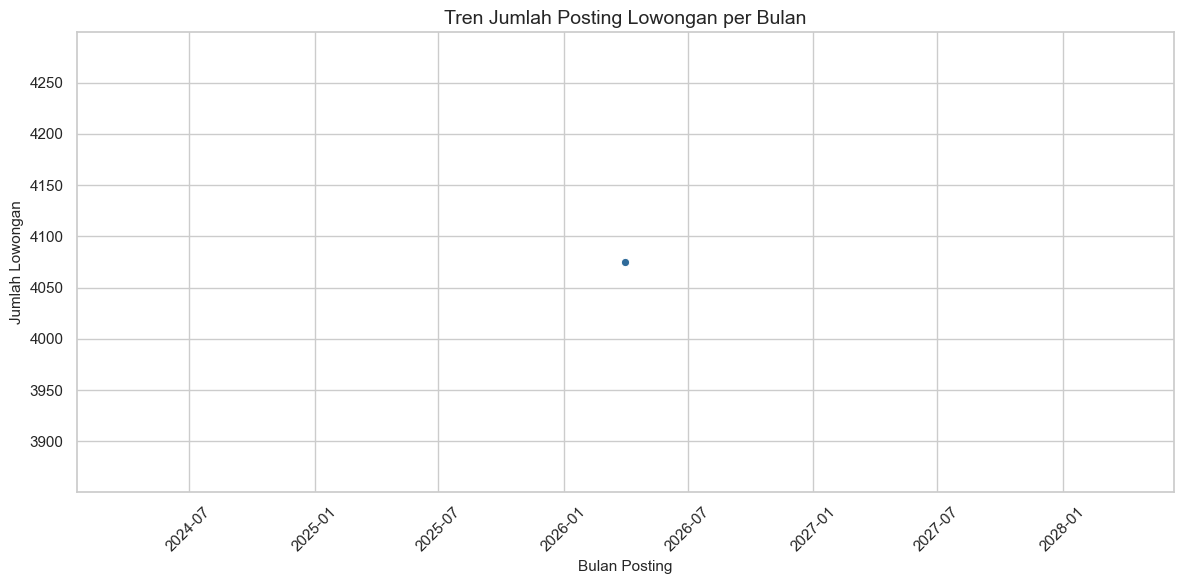

,posting_month,jumlah_lowongan
0,2026-04-01,4075


In [9]:
jobs['listed_time'] = pd.to_datetime(jobs['listed_time'], errors='coerce')
jobs['original_listed_time'] = pd.to_datetime(jobs['original_listed_time'], errors='coerce')

jobs['posting_month'] = jobs['listed_time'].dt.to_period('M').dt.to_timestamp()
monthly_postings = jobs.dropna(subset=['posting_month']).groupby('posting_month').size().reset_index(name='jumlah_lowongan')

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_postings, x='posting_month', y='jumlah_lowongan', marker='o', color='#2F6B9A')
plt.title('Tren Jumlah Posting Lowongan per Bulan')
plt.xlabel('Bulan Posting')
plt.ylabel('Jumlah Lowongan')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly_postings

**Insight:** Tren posting memperlihatkan periode rekrutmen yang lebih aktif. Pola ini dapat membantu dashboard menampilkan momentum pasar kerja dan membantu CareerPath AI memberi rekomendasi berdasarkan lowongan yang lebih baru.

## 5. Skill Analysis

Bagian ini menggabungkan tabel relasi lowongan-skill dengan master skill, lalu menghubungkannya ke dataset lowongan bersih. Hasil merge digunakan untuk menganalisis skill paling dicari, skill per pekerjaan, skill per level pengalaman, dan skill per lokasi.

### A. Merge Data Skill

Proses merge dilakukan dalam dua tahap:
1. `job_skills` digabung dengan `skills` berdasarkan `skill_abr` untuk mendapatkan `skill_name`.
2. Hasil tersebut digabung dengan `job_clean_final` berdasarkan `job_id` agar setiap skill memiliki konteks pekerjaan, lokasi, dan experience level.

In [10]:
skill_mapping = job_skills.merge(skills, on='skill_abr', how='left')

skill_analysis = skill_mapping.merge(
    jobs[['job_id', 'title', 'location', 'formatted_experience_level', 'formatted_work_type']],
    on='job_id',
    how='inner'
)

skill_analysis = skill_analysis[[
    'job_id',
    'title',
    'skill_abr',
    'skill_name',
    'location',
    'formatted_experience_level',
    'formatted_work_type'
]].copy()

print(f'Shape hasil merge skill: {skill_analysis.shape[0]:,} baris x {skill_analysis.shape[1]:,} kolom')
print(f'Jumlah skill tanpa nama setelah merge: {skill_analysis["skill_name"].isna().sum():,}')
skill_analysis.head()

Shape hasil merge skill: 6,844 baris x 7 kolom
Jumlah skill tanpa nama setelah merge: 0


,job_id,title,skill_abr,skill_name,location,formatted_experience_level,formatted_work_type
0,4401464202,junior creative designer,DSGN,Design,Jakarta,not_specified,Full-time
1,4401464202,junior creative designer,ART,Art/Creative,Jakarta,not_specified,Full-time
2,4401464202,junior creative designer,IT,Information Technology,Jakarta,not_specified,Full-time
3,4398796723,sales specialist,SALE,Sales,Jakarta Metropolitan Area,not_specified,Full-time
4,4398796723,sales specialist,BD,Business Development,Jakarta Metropolitan Area,not_specified,Full-time


**Insight:** Dataset hasil merge menjadi fondasi utama untuk analisis skill. Struktur ini sudah sesuai untuk kebutuhan AI Engineer karena setiap baris merepresentasikan hubungan antara satu lowongan dan satu skill.

### B. Top 15 Skill Paling Dicari

Frekuensi skill menunjukkan kompetensi yang paling banyak muncul di lowongan kerja.

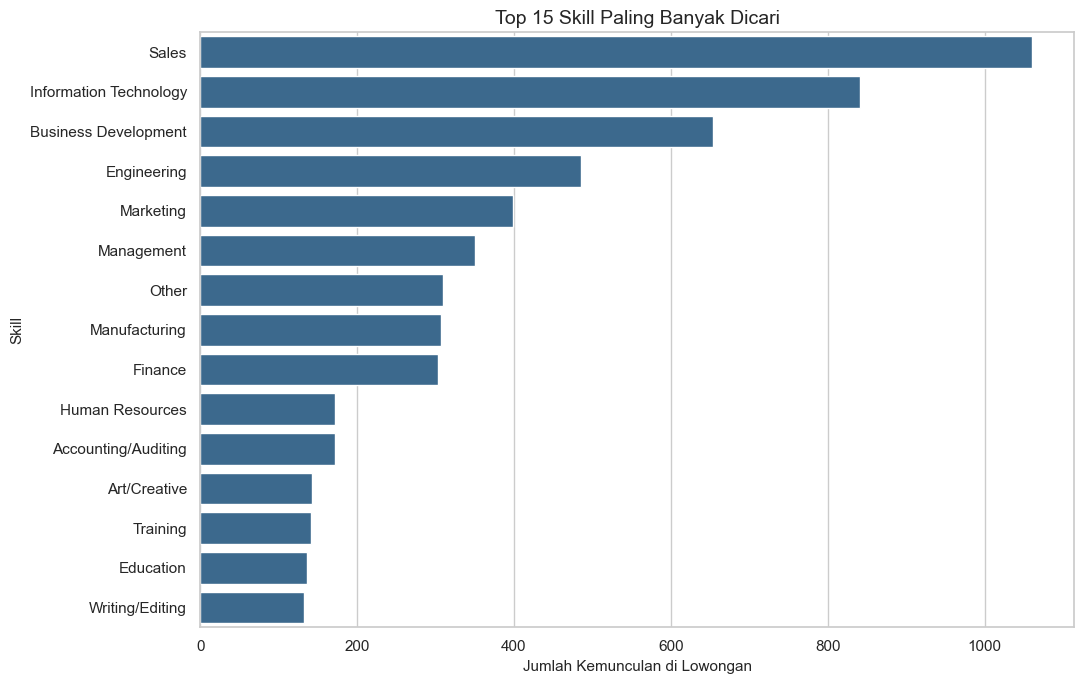

,skill_name,jumlah_lowongan
0,Sales,1061
1,Information Technology,841
2,Business Development,654
3,Engineering,485
4,Marketing,399
5,Management,351
6,Other,309
7,Manufacturing,307
8,Finance,303
9,Human Resources,172


In [11]:
top_skills = skill_analysis['skill_name'].value_counts().head(15).reset_index()
top_skills.columns = ['skill_name', 'jumlah_lowongan']

plt.figure(figsize=(11, 7))
sns.barplot(data=top_skills, x='jumlah_lowongan', y='skill_name', color='#2F6B9A')
plt.title('Top 15 Skill Paling Banyak Dicari')
plt.xlabel('Jumlah Kemunculan di Lowongan')
plt.ylabel('Skill')
plt.tight_layout()
plt.show()

top_skills

**Insight:** Skill dengan frekuensi tertinggi dapat diprioritaskan sebagai fitur utama dalam CareerPath AI. Skill ini juga bisa menjadi rekomendasi pembelajaran bagi pengguna yang ingin meningkatkan peluang cocok dengan lebih banyak lowongan.

### C. Skill Berdasarkan Job Title

Analisis ini mengambil 5 job title teratas, lalu menampilkan skill yang paling sering muncul pada masing-masing title.

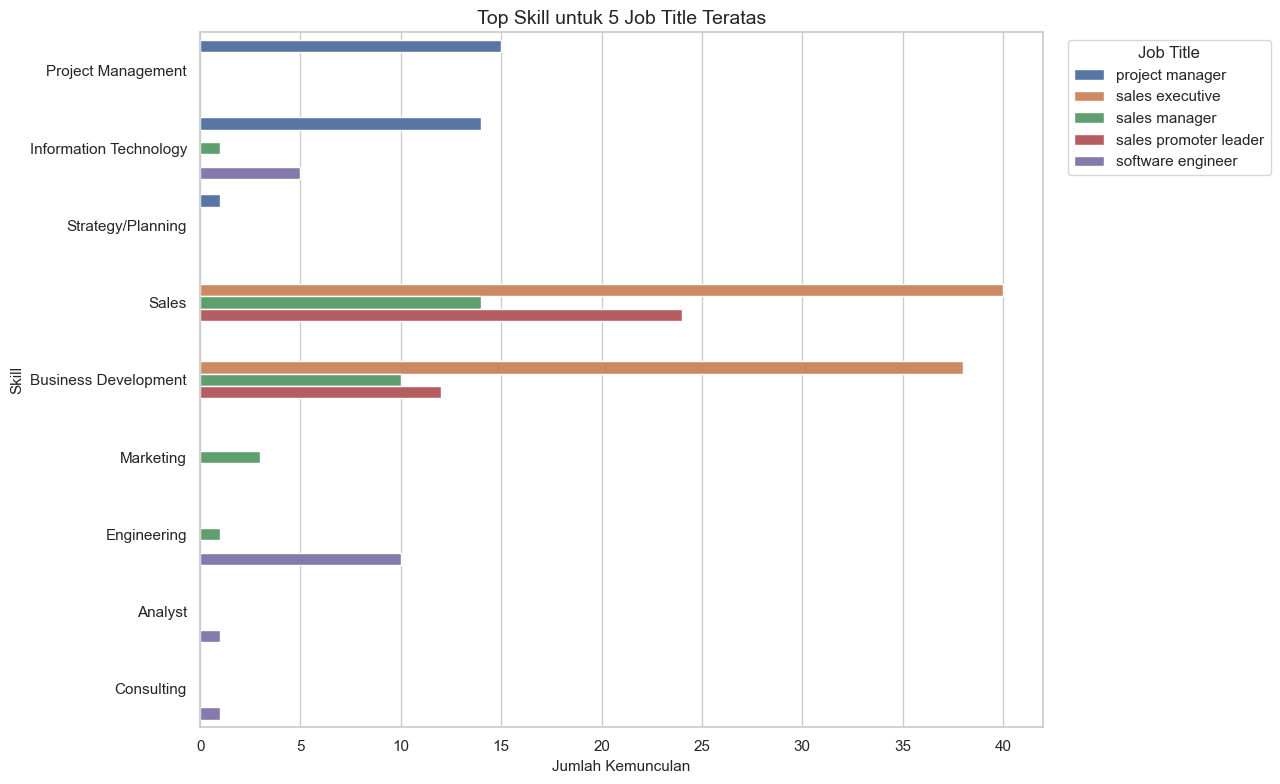

,title,skill_name,jumlah_lowongan
0,project manager,Project Management,15
1,project manager,Information Technology,14
2,project manager,Strategy/Planning,1
3,sales executive,Sales,40
4,sales executive,Business Development,38
5,sales manager,Sales,14
6,sales manager,Business Development,10
7,sales manager,Marketing,3
8,sales manager,Engineering,1
9,sales manager,Information Technology,1


In [12]:
top_5_titles = jobs['title'].value_counts().head(5).index.tolist()

skills_by_title = (
    skill_analysis[skill_analysis['title'].isin(top_5_titles)]
    .groupby(['title', 'skill_name'])
    .size()
    .reset_index(name='jumlah_lowongan')
    .sort_values(['title', 'jumlah_lowongan'], ascending=[True, False])
)

top_skills_by_title = skills_by_title.groupby('title').head(5).reset_index(drop=True)

plt.figure(figsize=(13, 8))
sns.barplot(data=top_skills_by_title, x='jumlah_lowongan', y='skill_name', hue='title')
plt.title('Top Skill untuk 5 Job Title Teratas')
plt.xlabel('Jumlah Kemunculan')
plt.ylabel('Skill')
plt.legend(title='Job Title', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

top_skills_by_title

**Insight:** Setiap job title memiliki kombinasi skill yang berbeda. Informasi ini sangat penting untuk fitur rekomendasi karena model tidak cukup hanya mencocokkan nama pekerjaan, tetapi perlu memahami skill inti di balik setiap role.

### D. Skill Berdasarkan Experience Level

Level pengalaman dikelompokkan menjadi kategori analitis: `junior`, `senior`, `intern`, dan `other`. Tujuannya adalah melihat apakah kebutuhan skill berbeda antar level karier.

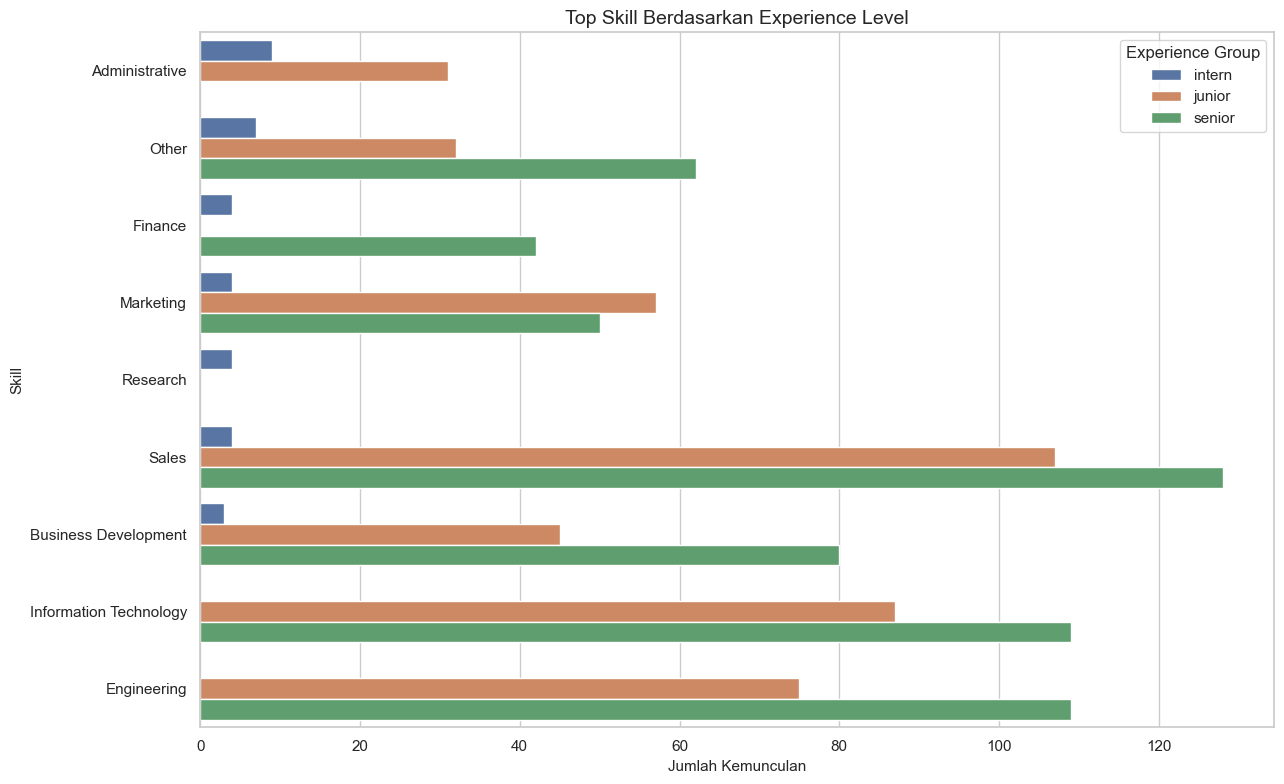

,experience_group,skill_name,jumlah_lowongan
0,intern,Administrative,9
1,intern,Other,7
2,intern,Finance,4
3,intern,Marketing,4
4,intern,Research,4
5,intern,Sales,4
6,intern,Business Development,3
7,junior,Sales,107
8,junior,Information Technology,87
9,junior,Engineering,75


In [13]:
def categorize_experience_level(level):
    level = str(level).lower()
    if 'intern' in level:
        return 'intern'
    if 'entry' in level or 'associate' in level:
        return 'junior'
    if 'senior' in level or 'director' in level or 'executive' in level or 'mid' in level:
        return 'senior'
    return 'other'

skill_analysis['experience_group'] = skill_analysis['formatted_experience_level'].apply(categorize_experience_level)

skill_by_experience = (
    skill_analysis[skill_analysis['experience_group'].isin(['junior', 'senior', 'intern'])]
    .groupby(['experience_group', 'skill_name'])
    .size()
    .reset_index(name='jumlah_lowongan')
    .sort_values(['experience_group', 'jumlah_lowongan'], ascending=[True, False])
)

top_skill_by_experience = skill_by_experience.groupby('experience_group').head(7).reset_index(drop=True)

plt.figure(figsize=(13, 8))
sns.barplot(data=top_skill_by_experience, x='jumlah_lowongan', y='skill_name', hue='experience_group')
plt.title('Top Skill Berdasarkan Experience Level')
plt.xlabel('Jumlah Kemunculan')
plt.ylabel('Skill')
plt.legend(title='Experience Group')
plt.tight_layout()
plt.show()

top_skill_by_experience

**Insight:** Perbedaan skill antar level pengalaman dapat membantu CareerPath AI memberikan rekomendasi yang lebih personal. Untuk fresh graduate atau junior, sistem dapat menekankan skill dasar yang sering muncul, sedangkan untuk senior sistem dapat menambahkan skill manajerial, teknis lanjut, atau domain-specific.

### E. Skill Berdasarkan Lokasi

Analisis opsional ini melihat skill dominan di lokasi dengan jumlah lowongan terbesar.

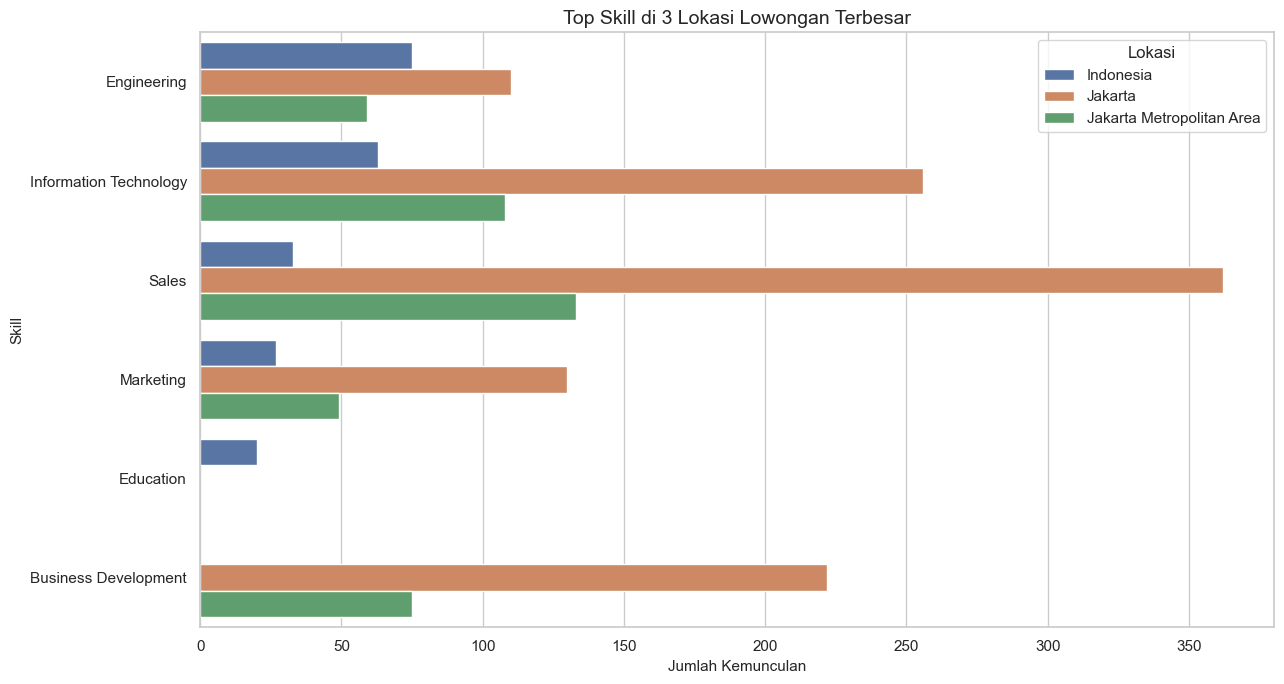

,location,skill_name,jumlah_lowongan
0,Indonesia,Engineering,75
1,Indonesia,Information Technology,63
2,Indonesia,Sales,33
3,Indonesia,Marketing,27
4,Indonesia,Education,20
5,Jakarta,Sales,362
6,Jakarta,Information Technology,256
7,Jakarta,Business Development,222
8,Jakarta,Marketing,130
9,Jakarta,Engineering,110


In [14]:
top_3_locations = jobs['location'].value_counts().head(3).index.tolist()

skill_by_location = (
    skill_analysis[skill_analysis['location'].isin(top_3_locations)]
    .groupby(['location', 'skill_name'])
    .size()
    .reset_index(name='jumlah_lowongan')
    .sort_values(['location', 'jumlah_lowongan'], ascending=[True, False])
)

top_skill_by_location = skill_by_location.groupby('location').head(5).reset_index(drop=True)

plt.figure(figsize=(13, 7))
sns.barplot(data=top_skill_by_location, x='jumlah_lowongan', y='skill_name', hue='location')
plt.title('Top Skill di 3 Lokasi Lowongan Terbesar')
plt.xlabel('Jumlah Kemunculan')
plt.ylabel('Skill')
plt.legend(title='Lokasi')
plt.tight_layout()
plt.show()

top_skill_by_location

**Insight:** Skill dominan per lokasi membantu dashboard menampilkan kebutuhan kompetensi berbasis wilayah. Fitur ini berguna untuk pengguna yang ingin mencari pekerjaan di kota tertentu atau membandingkan peluang antar lokasi.

## 6. Insight Strategis

Berdasarkan EDA dan Skill Analysis:

1. **Skill paling penting tahun ini** dapat dilihat dari daftar Top 15 Skill. Skill dengan frekuensi tertinggi adalah kandidat utama untuk dijadikan indikator matching antara CV dan lowongan.
2. **Job market cenderung terkonsentrasi pada role yang berulang muncul di Top Job Title**, sehingga dashboard perlu menonjolkan role-role populer sebagai kategori eksplorasi utama.
3. **Peluang fresh graduate bergantung pada proporsi lowongan entry-level dan internship.** Jika kategori ini lebih kecil dibanding senior atau not specified, CareerPath AI perlu membantu pengguna junior menemukan skill gap agar lebih kompetitif.
4. **Experience level sering kali tidak cukup eksplisit**, sehingga model AI sebaiknya tidak bergantung hanya pada kolom `formatted_experience_level`. Informasi dari `title`, `description`, dan `skill_name` perlu digabungkan.
5. **Untuk CareerPath AI**, hasil analisis skill dapat digunakan sebagai basis feature engineering, seperti skill frequency, skill overlap score, skill gap, dan rekomendasi learning path.

## 7. Output Dataset untuk Tahap Berikutnya

Dataset `skill_analysis_ready.csv` dibuat sebagai output lanjutan. Dataset ini minimal berisi `job_id`, `title`, `skill_name`, `location`, dan `formatted_experience_level`, serta beberapa kolom tambahan yang berguna untuk dashboard dan model.

In [15]:
skill_analysis_ready = skill_analysis[[
    'job_id',
    'title',
    'skill_name',
    'location',
    'formatted_experience_level',
    'formatted_work_type',
    'experience_group'
]].copy()

skill_analysis_ready = skill_analysis_ready.dropna(subset=['job_id', 'title', 'skill_name'])
skill_analysis_ready.to_csv('skill_analysis_ready.csv', index=False)

print(f'skill_analysis_ready.csv berhasil disimpan dengan shape: {skill_analysis_ready.shape[0]:,} baris x {skill_analysis_ready.shape[1]:,} kolom')
skill_analysis_ready.head()

skill_analysis_ready.csv berhasil disimpan dengan shape: 6,776 baris x 7 kolom


,job_id,title,skill_name,location,formatted_experience_level,formatted_work_type,experience_group
0,4401464202,junior creative designer,Design,Jakarta,not_specified,Full-time,other
1,4401464202,junior creative designer,Art/Creative,Jakarta,not_specified,Full-time,other
2,4401464202,junior creative designer,Information Technology,Jakarta,not_specified,Full-time,other
3,4398796723,sales specialist,Sales,Jakarta Metropolitan Area,not_specified,Full-time,other
4,4398796723,sales specialist,Business Development,Jakarta Metropolitan Area,not_specified,Full-time,other


## 8. Kesimpulan Akhir

### 5 Insight Utama

1. Job title dengan frekuensi tertinggi menunjukkan role dengan permintaan pasar terbesar dan layak dijadikan kategori utama pada dashboard.
2. Lokasi dengan jumlah lowongan terbesar menunjukkan pusat peluang kerja yang dapat digunakan untuk filter geografis dan insight pasar.
3. Work type dominan memberikan gambaran pola rekrutmen, misalnya apakah pasar lebih condong ke full-time, contract, part-time, atau internship.
4. Skill paling banyak dicari menjadi sinyal utama untuk matching CV-lowongan dan rekomendasi pengembangan skill.
5. Skill berbeda antar job title dan experience level, sehingga CareerPath AI perlu melakukan matching berbasis kombinasi role, skill, lokasi, dan level pengalaman.

### Pemanfaatan untuk Dashboard Streamlit

Hasil analisis dapat digunakan untuk membuat komponen dashboard seperti Top Job Title, Top Location, distribusi Work Type, distribusi Experience Level, tren posting bulanan, Top Skill, dan Skill per Job Title atau Lokasi.

### Pemanfaatan untuk AI Engineer

Dataset `skill_analysis_ready.csv` dapat digunakan untuk membangun fitur skill overlap, skill gap analysis, rekomendasi lowongan berbasis skill, dan ranking lowongan berdasarkan kecocokan CV pengguna.